# 04 系统蓝图：多工况锂电池 RUL 深度学习系统

目标：把研究流程从 Notebook 验证升级为**可复现实验系统**。

本 Notebook 对应的模块化代码在 `src/rul_system/`：
- `data.py`：数据加载、工况编码、窗口化
- `models.py`：条件感知 Transformer
- `train.py`：训练、预测与指标

In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch

PROJECT_ROOT = r"C:\\Users\\PLUTO\\Desktop\\battery-rul"
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.rul_system.data import (
    load_battery_raw_parameters,
    default_condition_map,
    build_protocol_splits,
    prepare_condition_aware_dataloaders,
)
from src.rul_system.models import ConditionAwareTransformer, BaselineLSTM
from src.rul_system.train import (
    train_model,
    predict,
    compute_regression_metrics,
    run_protocol_experiment,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


## 1) 数据与实验协议

这里给一个可执行的起点：
- 训练：室温电池 + 部分低温电池
- 测试：低温未见电池 `B0053`（跨工况外推）

你后续可以替换为 LOBO/LOCO 更严格协议。

In [3]:
DATA_DIR_GROUP1 = os.path.join(PROJECT_ROOT, "data\\processed\\1. BatteryAgingARC-FY08Q4")
DATA_DIR_GROUP6 = os.path.join(PROJECT_ROOT, "data\\processed\\6. BatteryAgingARC_53_54_55_56")

room_ids = ["B0005", "B0006", "B0007", "B0018"]
cold_ids = ["B0053", "B0054", "B0055", "B0056"]

room_data = load_battery_raw_parameters(DATA_DIR_GROUP1, room_ids)
cold_data = load_battery_raw_parameters(DATA_DIR_GROUP6, cold_ids)
all_data = {**room_data, **cold_data}

condition_map = default_condition_map()

train_ids = ["B0005", "B0006", "B0007", "B0018", "B0054", "B0055", "B0056"]
test_id = "B0053"

print("Train IDs:", train_ids)
print("Test ID:", test_id)

Train IDs: ['B0005', 'B0006', 'B0007', 'B0018', 'B0054', 'B0055', 'B0056']
Test ID: B0053


## 2) 构建 DataLoader（训练集拟合缩放器，测试集仅变换）

In [4]:
SEQ_LENGTH = 10
BATCH_SIZE = 32

train_loader, test_loader, scaler_y, test_actual_capacity = prepare_condition_aware_dataloaders(
    battery_dict=all_data,
    train_ids=train_ids,
    test_id=test_id,
    condition_map=condition_map,
    seq_length=SEQ_LENGTH,
    batch_size=BATCH_SIZE,
)

print("Train batches:", len(train_loader))
print("Test samples:", len(test_loader))

Train batches: 28
Test samples: 45


## 3) 模型训练（条件感知 Transformer）

In [5]:
model = ConditionAwareTransformer(
    input_dim=5,
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    dropout=0.1,
    max_seq_len=128,
)

history = train_model(
    model=model,
    train_loader=train_loader,
    epochs=40,
    lr=1e-3,
    device=device,
)

print("Final train loss:", history[-1])

Final train loss: 0.0010497234803291836


## 4) 测试评估与可视化

==== Test Metrics (B0053) ====
RMSE: 0.0486 Ah
MAE: 0.0403 Ah
MAPE: 3.8423 %


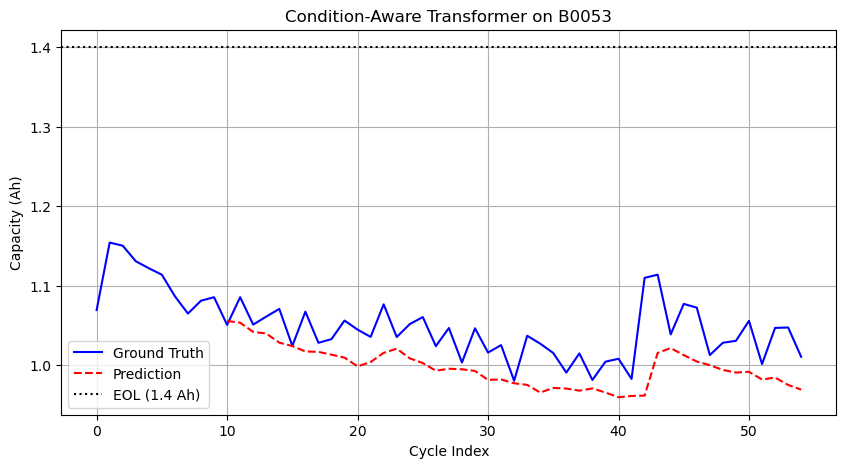

In [6]:
preds_real = predict(model, test_loader, scaler_y=scaler_y, device=device)
y_true = test_actual_capacity[SEQ_LENGTH:]
metrics = compute_regression_metrics(y_true, preds_real)

print("==== Test Metrics (" + test_id + ") ====")
for k, v in metrics.items():
    suffix = "%" if k == "MAPE" else "Ah"
    print(f"{k}: {v:.4f} {suffix}")

plt.figure(figsize=(10, 5))
plt.plot(range(len(test_actual_capacity)), test_actual_capacity, label="Ground Truth", color="blue")
plt.plot(range(SEQ_LENGTH, len(test_actual_capacity)), preds_real, label="Prediction", color="red", linestyle="--")
plt.axhline(y=1.4, color="black", linestyle=":", label="EOL (1.4 Ah)")
plt.title(f"Condition-Aware Transformer on {test_id}")
plt.xlabel("Cycle Index")
plt.ylabel("Capacity (Ah)")
plt.legend()
plt.grid(True)
plt.show()

## 5) 研究实践说明（为什么这是经典做法）

是的，这是非常典型的科研工程化路径：
1. Notebook 做假设验证与结果展示；
2. 把稳定逻辑沉淀成 `.py` 模块；
3. 每次实验只改配置与协议，不改核心代码；
4. 最终形成可复现实验流水线。

## 6) V1 系统实验：三协议 + 双模型对照

> 目标：在统一协议下比较主模型（Transformer）与基线（LSTM）。

> 说明：为保证 notebook 可快速运行，这里每个协议先跑前 1 个 split 作为冒烟验证；完整实验可去掉切片限制。

In [7]:
available_ids = sorted([bid for bid in all_data.keys() if bid in condition_map])
protocols = build_protocol_splits(available_ids, condition_map)

print("可用电池:", available_ids)
print("same_condition splits:", len(protocols["same_condition"]))
print("lobo splits:", len(protocols["lobo"]))
print("loco splits:", len(protocols["loco"]))

train_kwargs = {"epochs": 20, "lr": 1e-3}

# 冒烟验证：每个协议先取前1个split，确保系统流程完整打通
protocol_subset = {
    "same_condition": protocols["same_condition"][:1],
    "lobo": protocols["lobo"][:1],
    "loco": protocols["loco"][:1],
}

all_records = []
for protocol_name, splits in protocol_subset.items():
    if not splits:
        continue

    tf_records = run_protocol_experiment(
        battery_dict=all_data,
        condition_map=condition_map,
        protocol_splits=splits,
        model_cls=ConditionAwareTransformer,
        model_kwargs={
            "input_dim": 5,
            "d_model": 64,
            "nhead": 4,
            "num_layers": 2,
            "dim_feedforward": 128,
            "dropout": 0.1,
            "max_seq_len": 128,
        },
        train_kwargs=train_kwargs,
        seq_length=SEQ_LENGTH,
        batch_size=BATCH_SIZE,
        device=device,
    )
    for r in tf_records:
        r["model"] = "Transformer"
        r["protocol"] = protocol_name

    lstm_records = run_protocol_experiment(
        battery_dict=all_data,
        condition_map=condition_map,
        protocol_splits=splits,
        model_cls=BaselineLSTM,
        model_kwargs={
            "input_dim": 5,
            "hidden_dim": 64,
            "num_layers": 2,
            "dropout": 0.1,
        },
        train_kwargs=train_kwargs,
        seq_length=SEQ_LENGTH,
        batch_size=BATCH_SIZE,
        device=device,
    )
    for r in lstm_records:
        r["model"] = "LSTM"
        r["protocol"] = protocol_name

    all_records.extend(tf_records)
    all_records.extend(lstm_records)

df_v1 = pd.DataFrame(all_records)
display(df_v1)

if not df_v1.empty:
    summary = df_v1.groupby(["protocol", "model"])[["RMSE", "MAE", "MAPE"]].mean().reset_index()
    print("\n=== V1 协议均值结果（冒烟）===")
    display(summary)

可用电池: ['B0005', 'B0006', 'B0007', 'B0018', 'B0053', 'B0054', 'B0055', 'B0056']
same_condition splits: 8
lobo splits: 8
loco splits: 2


,protocol_group,train_ids,test_id,RMSE,MAE,MAPE,num_points,model,protocol
0,T24_I2,"[B0006, B0007, B0018]",B0005,0.127417,0.123925,8.040869,158,Transformer,same_condition
1,T24_I2,"[B0006, B0007, B0018]",B0005,0.139240,0.130015,8.774276,158,LSTM,same_condition
2,mixed,"[B0006, B0007, B0018, B0053, B0054, B0055, B0056]",B0005,0.045955,0.037828,2.356812,158,Transformer,lobo
3,mixed,"[B0006, B0007, B0018, B0053, B0054, B0055, B0056]",B0005,0.126073,0.121923,8.007535,158,LSTM,lobo
4,T24_I2,"[B0053, B0054, B0055, B0056]",B0005,0.443452,0.409121,25.359499,158,Transformer,loco
5,T24_I2,"[B0053, B0054, B0055, B0056]",B0006,0.508757,0.461642,28.995939,158,Transformer,loco
6,T24_I2,"[B0053, B0054, B0055, B0056]",B0007,0.703617,0.689324,41.864429,158,Transformer,loco
7,T24_I2,"[B0053, B0054, B0055, B0056]",B0018,1.097131,1.089135,70.737404,122,Transformer,loco
8,T24_I2,"[B0053, B0054, B0055, B0056]",B0005,0.950636,0.934248,59.546749,158,LSTM,loco
9,T24_I2,"[B0053, B0054, B0055, B0056]",B0006,0.723309,0.687272,44.080929,158,LSTM,loco



=== V1 协议均值结果（冒烟）===


,protocol,model,RMSE,MAE,MAPE
0,lobo,LSTM,0.126073,0.121923,8.007535
1,lobo,Transformer,0.045955,0.037828,2.356812
2,loco,LSTM,0.768912,0.748170,47.451386
3,loco,Transformer,0.688239,0.662306,41.739318
4,same_condition,LSTM,0.139240,0.130015,8.774276
5,same_condition,Transformer,0.127417,0.123925,8.040869
